# Trabalho de Fundamentos em Ciência de Dados
## Tema: Análise do Histórico e Correlação do Bitcoin
### Alunos
- Pedro Henrique de Oliveira Covisi
- Lucca Teodoro Vaz

### Instruções para o Trabalho
1) Descrição do problema e dos dados
- Apresentar o tema escolhido;
- Descrever a origem da base de dados;
- Explicar os objetivos ou perguntas que serão investigadas.
2) Preparação dos dados
- Identificar e tratar valores ausentes ou inconsistentes;
- Remover duplicidades, quando necessário;
- Descrever as etapas de limpeza e pré-processamento dos dados.
3) Análise exploratória dos dados
Realizar análises utilizando tabelas e gráficos para responder às perguntas propostas.
Exemplos:
- Distribuição das variáveis;
- Comparação entre grupos;
- Associações entre variáveis;
- Identificação de padrões ou tendências.
Devem ser utilizados pelo menos três tipos diferentes de visualização de dados, como histogramas, gráficos de barras, gráficos de dispersão, boxplots, entre outros.
4) Resultados e conclusões
- Apresentar os principais resultados encontrados;
- Discutir possíveis limitações da base de dados;
- Destacar conclusões e aplicações do estudo

## 1) Descrição do Problema e dos Dados

### 1.1) Tema Escolhido

O tema escolhido foi a análise do histórico e da correlação do Bitcoin com outros ativos financeiros. Assim, nosso objetivo é fazer uma análise profunda da cotação do Bitcoin e da sua correlação, que mudou ao longo dos anos, com outros ativos financeiros relevantes, como o Petróleo, Bolsas Americana e Brasileira, Ouro, Ethereum (segunda maior criptomoeda), Títulos do Tesouro, entre outros. Escolhemos esse tema devido ao grande interesse que temos no mercado financeiro e na influência que o Bitcoin, e outras criptomoedas, vem ganhando com o passar do tempo.

### 1.2) Origem da Base de Dados

Para a realização deste trabalho, são utilizadas duas fontes de dados principais:

1. **Yahoo Finance API (via biblioteca yfinance):**
   Os dados financeiros são coletados dinamicamente utilizando a biblioteca `yfinance` em Python, cobrindo o período a partir de **09/11/2017**. São extraídas as métricas diárias de preço de Abertura (*Open*), Máxima (*High*), Mínima (*Low*) e Fechamento (*Close*) para os seguintes ativos:
   - **Bitcoin (BTC-USD):** Principal criptomoeda e foco central deste estudo.
   - **Ethereum (ETH-USD):** Segunda maior criptomoeda do mercado, para análise de correlação intrassetorial.
   - **S&P 500 (^GSPC):** Índice das 500 maiores empresas dos EUA, representando o mercado de ações americano.
   - **Nasdaq (^IXIC):** Índice de ações composto majoritariamente por empresas de tecnologia.
   - **Ibovespa (^BVSP):** Principal índice de ações do mercado brasileiro.
   - **Ouro (GC=F):** Contratos futuros de ouro, utilizado como commodity de segurança/reserva de valor.
   - **Petróleo (CL=F):** Contratos futuros de petróleo bruto (WTI), representando a principal commodity energética.
   - **Dólar (DX-Y.NYB):** Índice DXY, que mensura o desempenho do dólar americano contra uma cesta de moedas fortes.

2. **Base de Dados Histórica do Bitcoin (bitcoin_dataset.csv):**
   Um conjunto de dados histórico local armazenado em `data/bitcoin_dataset.csv` com dados diários do preço do Bitcoin desde **17/09/2014**. As variáveis incluem as datas e os valores de Abertura (*Open*), Máxima (*High*), Mínima (*Low*), Fechamento (*Close*), Fechamento Ajustado (*Adj Close*) e Volume de negociação.

### 1.3) Objetivos e Perguntas de Pesquisa

1) Fornecer uma breve contextualização sobre o Bitcoin;
2) Fazer observações com relação ao preço do Bitcoin (como volatilidade, drawdown, entre outros);
3) Analisar a correlação do Bitcoin com outros ativos financeiros;
4) Representar essa correlação de forma gráfica e matemática;
5) Realizar análises sobre a cotação do Bitcoin com base em seu histórico e correlação com outros ativos.

## 2) Preparação dos Dados

### 2.1) Importação e Limpeza dos Dados dos Ativos Financeiros

Importando as bibliotecas

In [58]:
# Importação das bibliotecas necessárias para análise de dados, visualização e coleta de dados financeiros
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


Importando os dados financeiros do Yahoo Finance

In [59]:
# Definição dos tickers dos ativos a serem importados
tickers_ativos = [
    "BTC-USD", # Bitcoin
    "ETH-USD", # Ethereum
    "^GSPC", # S&P 500
    "^IXIC", # Nasdaq
    "^BVSP", # Bovespa
    "GC=F", # Ouro
    "CL=F", # Petróleo
    "DX-Y.NYB", # Dólar
]

# Download dos dados históricos dos ativos
df_ativos = yf.download(tickers_ativos, start="2015-01-01")

# Filtragem das métricas de preço desejadas
metricas_desejadas = ['Open', 'High', 'Low', 'Close']
df_filtrado = df_ativos[metricas_desejadas]

df_ativos = df_filtrado
# Visualização das primeiras linhas dos dados importados
df_ativos.head(20)


[*********************100%***********************]  8 of 8 completed


Price             Open                                                      \
Ticker         BTC-USD       CL=F   DX-Y.NYB ETH-USD         GC=F    ^BVSP   
Date                                                                         
2015-01-01  320.434998        NaN        NaN     NaN          NaN      NaN   
2015-01-02  314.079010  53.759998  90.360001     NaN  1184.000000  50005.0   
2015-01-03  314.846008        NaN        NaN     NaN          NaN      NaN   
2015-01-04  281.145996        NaN        NaN     NaN          NaN      NaN   
2015-01-05  265.084015  52.610001  91.129997     NaN  1180.300049  48512.0   
2015-01-06  274.610992  50.000000  91.379997     NaN  1203.500000  47517.0   
2015-01-07  286.076996  48.000000  91.750000     NaN  1219.199951  48006.0   
2015-01-08  294.135010  48.779999  91.940002     NaN  1207.000000  49463.0   
2015-01-09  282.382996  48.919998  92.309998     NaN  1211.099976  49955.0   
2015-01-10  287.303009        NaN        NaN     NaN          NaN      NaN   
2015-01-11  274.608002        NaN        NaN     NaN          NaN      NaN   
2015-01-12  266.145996  48.189999  91.879997     NaN  1224.199951  48840.0   
2015-01-13  267.394012  45.689999  92.029999     NaN  1239.199951  48144.0   
2015-01-14  223.893997  46.160000  92.230003     NaN  1229.599976  48038.0   
2015-01-15  176.897003  48.599998  92.160004     NaN  1231.500000  47648.0   
2015-01-16  209.070007  46.349998  92.099998     NaN  1256.099976  48028.0   
2015-01-17  207.834000        NaN        NaN     NaN          NaN      NaN   
2015-01-18  200.050003        NaN        NaN     NaN          NaN      NaN   
2015-01-19  211.470993        NaN        NaN     NaN          NaN  49009.0   
2015-01-20  212.906998  48.689999  92.660004     NaN  1278.900024  47759.0   

Price                                       High             ...          Low  \
Ticker            ^GSPC        ^IXIC     BTC-USD       CL=F  ...        ^GSPC   
Date                                                         ...                
2015-01-01          NaN          NaN  320.434998        NaN  ...          NaN   
2015-01-02  2058.899902  4760.240234  315.838989  55.110001  ...  2046.040039   
2015-01-03          NaN          NaN  315.149994        NaN  ...          NaN   
2015-01-04          NaN          NaN  287.230011        NaN  ...          NaN   
2015-01-05  2054.439941  4700.339844  278.341003  52.730000  ...  2017.339966   
2015-01-06  2022.150024  4666.850098  287.553009  50.369999  ...  1992.439941   
2015-01-07  2005.550049  4626.839844  298.753998  49.310001  ...  2005.550049   
2015-01-08  2030.609985  4689.540039  294.135010  49.650002  ...  2030.609985   
2015-01-09  2063.449951  4744.470215  291.114014  49.610001  ...  2038.329956   
2015-01-10          NaN          NaN  288.127014        NaN  ...          NaN   
2015-01-11          NaN          NaN  279.638000        NaN  ...          NaN   
2015-01-12  2046.130005  4714.069824  272.203003  48.189999  ...  2022.579956   
2015-01-13  2031.579956  4708.740234  268.277008  46.790001  ...  2008.250000   
2015-01-14  2018.400024  4610.759766  223.893997  48.910000  ...  1988.439941   
2015-01-15  2013.750000  4657.459961  229.067001  51.270000  ...  1991.469971   
2015-01-16  1992.250000  4566.379883  221.591003  48.869999  ...  1988.119995   
2015-01-17          NaN          NaN  211.731003        NaN  ...          NaN   
2015-01-18          NaN          NaN  218.695007        NaN  ...          NaN   
2015-01-19          NaN          NaN  216.727997        NaN  ...          NaN   
2015-01-20  2020.760010  4655.839844  215.240997  48.770000  ...  2004.489990   

Price                         Close                                \
Ticker            ^IXIC     BTC-USD       CL=F   DX-Y.NYB ETH-USD   
Date                                                                
2015-01-01          NaN  314.248993        NaN        NaN     NaN   
2015-01-02  4698.109863  315.032013  52.689999  91.080002     NaN

Mudando o nome das colunas para torná-las mais legíveis

In [60]:
# Renomeação das colunas para facilitar a identificação dos ativos
df_ativos = df_ativos.rename(columns={
    '^BVSP': 'Bovespa',
    'BTC-USD': 'Bitcoin',
    'ETH-USD': 'Ethereum',
    '^GSPC': 'SP500',
    '^IXIC': 'Nasdaq',
    'CL=F': 'Petróleo',
    'GC=F': 'Ouro',
    'DX-Y.NYB' : 'Dólar'
})


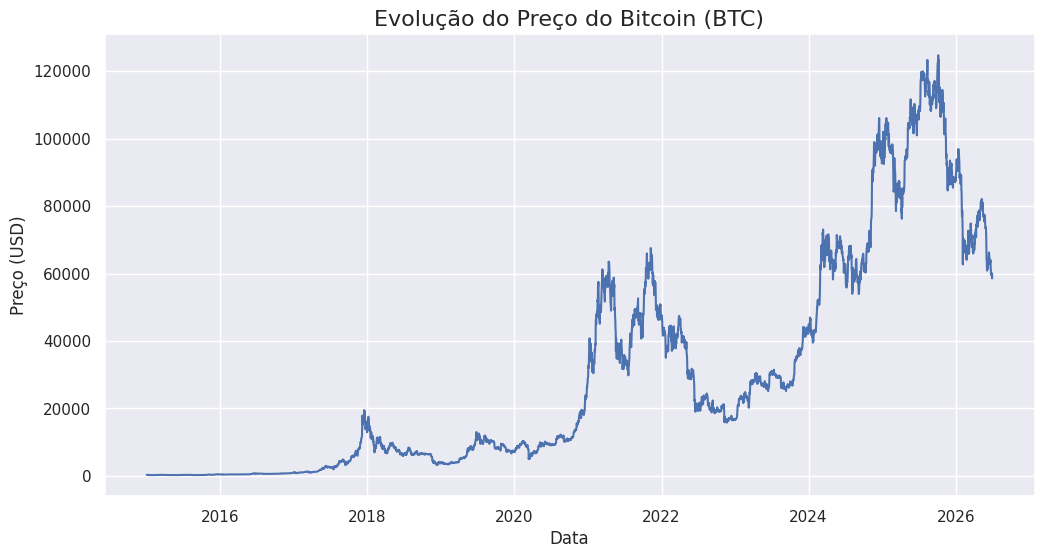

In [61]:
# Seleção do preço de fechamento do Bitcoin e ajuste do índice
btc_close = df_ativos[('Close','Bitcoin')].reset_index(name = 'Bitcoin')

# Configuração do tema visual dos gráficos
sns.set_theme(style='darkgrid')
plt.figure(figsize=(12,6))

# Plotagem do gráfico de linha para a evolução de preço
sns.lineplot(x='Date', y='Bitcoin', data=btc_close)

# Definição dos títulos e rótulos dos eixos
plt.title('Evolução do Preço do Bitcoin (BTC)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (USD)', fontsize=12)

# Exibição do gráfico gerado
plt.show()


### 2.2) Verificação e Tratamento de Dados Faltantes

In [62]:
# Verificação de dados faltantes nos ativos importados
dados = df_ativos
# Contagem e exibição do número de registros nulos por ativo e métrica
dados.isna().sum()


Price  Ticker  
Open   Bitcoin        0
       Petróleo    1310
       Dólar       1309
       Ethereum    1043
       Ouro        1311
       Bovespa     1348
       SP500       1310
       Nasdaq      1310
High   Bitcoin        0
       Petróleo    1310
       Dólar       1309
       Ethereum    1043
       Ouro        1311
       Bovespa     1348
       SP500       1310
       Nasdaq      1310
Low    Bitcoin        0
       Petróleo    1310
       Dólar       1309
       Ethereum    1043
       Ouro        1311
       Bovespa     1348
       SP500       1310
       Nasdaq      1310
Close  Bitcoin        0
       Petróleo    1310
       Dólar       1309
       Ethereum    1043
       Ouro        1311
       Bovespa     1348
       SP500       1310
       Nasdaq      1310
dtype: int64

A partir dessa verificação, apresentam-se vários dados faltantes, os quais já eram esperados. Isso ocorre porque, diferentemente dos mercados tradicionais, o Bitcoin e o Ethereum são negociados nos fins de semana e feriados.

Assim, para analisar a correlação entre o Bitcoin e outros ativos (exceto o Ethereum), existem duas opções:
1) Adicionar, artificialmente, os dados de fechamento do dia anterior para os dias com dados faltantes nos ativos financeiros tradicionais;
2) Ou excluir os dados do Bitcoin e do Ethereum nos fins de semana e feriados.

Para deixar a análise de correlação a mais assertiva possível, optamos pela segunda opção. Mas antes vamos copiar as colunas relativas ao Ethereum e ao Bitcoin para poder realizar análises mais assertivas entre as criptomoedas sem perder os dados dos fins de semana.

In [63]:
df_ativos

Price               Open                                                   \
Ticker           Bitcoin   Petróleo       Dólar     Ethereum         Ouro   
Date                                                                        
2015-01-01    320.434998        NaN         NaN          NaN          NaN   
2015-01-02    314.079010  53.759998   90.360001          NaN  1184.000000   
2015-01-03    314.846008        NaN         NaN          NaN          NaN   
2015-01-04    281.145996        NaN         NaN          NaN          NaN   
2015-01-05    265.084015  52.610001   91.129997          NaN  1180.300049   
...                  ...        ...         ...          ...          ...   
2026-06-27  60016.312500        NaN         NaN  1576.591187          NaN   
2026-06-28  59940.351562        NaN         NaN  1571.564453          NaN   
2026-06-29  59522.789062  70.500000  101.370003  1569.993408  4057.500000   
2026-06-30  60136.453125  70.430000  101.120003  1610.163818  4002.600098   
2026-07-01  58549.863281  69.980003  101.218002  1569.744873  4025.000000   

Price                                                         High             \
Ticker            Bovespa        SP500        Nasdaq       Bitcoin   Petróleo   
Date                                                                            
2015-01-01            NaN          NaN           NaN    320.434998        NaN   
2015-01-02   50005.000000  2058.899902   4760.240234    315.838989  55.110001   
2015-01-03            NaN          NaN           NaN    315.149994        NaN   
2015-01-04            NaN          NaN           NaN    287.230011        NaN   
2015-01-05   48512.000000  2054.439941   4700.339844    278.341003  52.730000   
...                   ...          ...           ...           ...        ...   
2026-06-27            NaN          NaN           NaN  60835.046875        NaN   
2026-06-28            NaN          NaN           NaN  60432.707031        NaN   
2026-06-29  173294.000000  7391.879883  25502.089844  60682.339844  71.150002   
2026-06-30  173205.000000  7441.270020  25824.470703  60173.218750  71.599998   
2026-07-01  172017.171875  7478.839844  26039.507812  59960.421875  70.190002   

Price       ...          Low                       Close             \
Ticker      ...        SP500        Nasdaq       Bitcoin   Petróleo   
Date        ...                                                       
2015-01-01  ...          NaN           NaN    314.248993        NaN   
2015-01-02  ...  2046.040039   4698.109863    315.032013  52.689999   
2015-01-03  ...          NaN           NaN    281.082001        NaN   
2015-01-04  ...          NaN           NaN    264.195007        NaN   
2015-01-05  ...  2017.339966   4641.459961    274.473999  50.040001   
...         ...          ...           ...           ...        ...   
2026-06-27  ...          NaN           NaN  59940.097656        NaN   
2026-06-28  ...          NaN           NaN  59532.339844        NaN   
2026-06-29  ...  7348.879883  25289.759766  60138.378906  70.750000   
2026-06-30  ...  7438.040039  25808.060547  58558.859375  69.500000   
2026-07-01  ...  7449.629883  25954.455078  59598.238281  68.720001   

Price                                                                         \
Ticker           Dólar     Ethereum         Ouro        Bovespa        SP500   
Date                                                                           
2015-01-01         NaN          NaN          NaN            NaN          NaN   
2015-01-02   91.080002          NaN  1186.000000   48512.000000  2058.199951   
2015-01-03         NaN          NaN          NaN            NaN          NaN   
2015-01-04         NaN          NaN          NaN            NaN          NaN   
2015-01-05   91.379997          NaN  1203.900024   47517.000000  2020.579956   
...                ...          ...          ...            ...          ...   
2026-06-27         NaN  1571.588257          NaN            NaN        

In [64]:
# Extração e cópia dos dados exclusivos do Bitcoin (selecionando o nível da coluna)
df_btc = df_ativos.xs('Bitcoin', level=1, axis=1).copy()

df_btc


Price,Open,High,Low,Close
Date,,,,
2015-01-01,320.434998,320.434998,314.002991,314.248993
2015-01-02,314.079010,315.838989,313.565002,315.032013
2015-01-03,314.846008,315.149994,281.082001,281.082001
2015-01-04,281.145996,287.230011,257.612000,264.195007
2015-01-05,265.084015,278.341003,265.084015,274.473999
...,...,...,...,...
2026-06-27,60016.312500,60835.046875,59794.621094,59940.097656
2026-06-28,59940.351562,60432.707031,58879.632812,59532.339844
2026-06-29,59522.789062,60682.339844,58856.187500,60138.378906


In [65]:
# Extração e cópia dos dados exclusivos do Ethereum
df_eth = df_ativos.xs('Ethereum', level=1, axis=1).copy()
# Exibição dos dados do Ethereum
df_eth


Price,Open,High,Low,Close
Date,,,,
2015-01-01,NaN,NaN,NaN,NaN
2015-01-02,NaN,NaN,NaN,NaN
2015-01-03,NaN,NaN,NaN,NaN
2015-01-04,NaN,NaN,NaN,NaN
2015-01-05,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-06-27,1576.591187,1607.865967,1561.972900,1571.588257
2026-06-28,1571.564453,1585.219727,1548.761963,1570.361206
2026-06-29,1569.993408,1633.645020,1550.036377,1610.205811


Em relação ao maior número de dados faltantes das bolsas em comparação com as commodities, como a quantidade é reduzida, resolvemos relevar e excluir as observações correspondentes.

Agora, realizamos a exclusão dos dados faltantes.

In [66]:
# Remoção de todas as linhas com valores ausentes
dados.dropna(inplace=True) 
# Verificação se restaram dados ausentes após a limpeza
dados.isna().sum()


Price  Ticker  
Open   Bitcoin     0
       Petróleo    0
       Dólar       0
       Ethereum    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
High   Bitcoin     0
       Petróleo    0
       Dólar       0
       Ethereum    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
Low    Bitcoin     0
       Petróleo    0
       Dólar       0
       Ethereum    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
Close  Bitcoin     0
       Petróleo    0
       Dólar       0
       Ethereum    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
dtype: int64

### 2.3) Cálculo dos Retornos Logarítmicos dos Ativos

Para garantir que as análises de correlação e os futuros modelos de previsão sejam estatisticamente consistentes, calculamos os retornos logarítmicos ($r_t = \ln(P_t / P_{t-1})$) a partir dos preços de fechamento diários (*Close*) de cada ativo.

**Principais motivos para usar os retornos logarítmicos:**
- **Simetria entre ganhos e perdas:** Por exemplo, se um ativo cai 50% e depois sobe 100% para retornar ao preço original, a soma simples dos retornos percentuais é +50% (o que é contraintuitivo), enquanto os retornos logarítmicos correspondentes têm a mesma magnitude mas sinais opostos, anulando-se mutuamente (soma igual a zero);
- **Aditividade no tempo:** O retorno logarítmico acumulado em vários períodos é a soma simples dos retornos de cada período individual;
- **Propriedades estatísticas:** Os retornos logarítmicos aproximam-se mais de uma distribuição normal.

In [67]:
# Filtragem dos preços de fechamento de cada ativo
df_fechamento = df_ativos['Close']

# Substituição de valores menores ou iguais a zero por NaN para evitar erros no logaritmo
df_fechamento = df_fechamento.mask(df_fechamento <= 0)

# Cálculo do retorno logarítmico diário de todos os ativos
df_retornos_log = np.log(df_fechamento / df_fechamento.shift(1))

# Remoção da primeira linha (que fica com NaN após o shift) e de outros NaNs resultantes
df_retornos_log.dropna(inplace=True)

# Exibição das primeiras linhas do DataFrame de retornos logarítmicos
df_retornos_log.head()


Ticker,Bitcoin,Petróleo,Dólar,Ethereum,Ouro,Bovespa,SP500,Nasdaq
Date,,,,,,,,
2017-11-10,-0.076400,-0.007550,-0.000530,-0.069790,-0.010321,-0.010545,-0.000898,0.000132
2017-11-13,-0.008901,0.000352,0.001059,0.056716,0.003844,0.004273,0.000983,0.000986
2017-11-14,0.011559,-0.018852,-0.007009,0.063948,0.003283,-0.023001,-0.002312,-0.002924
2017-11-16,0.170801,-0.010105,0.001065,-0.020065,-0.003204,0.023512,0.002622,0.008191
2017-11-17,-0.020886,0.025250,-0.002879,0.004432,0.014302,0.012676,-0.002629,-0.001547


## 3) Análise Exploratória dos Dados

### 3.1) Sazonalidade do Bitcoin

#### Como os dias da semana afetam os movimentos nos preços do Bitcoin?

In [68]:
# Seleção do preço de fechamento do Bitcoin com redefinição do índice para análise temporal
df_btc_close = df_btc['Close'].reset_index(name='Cotação')
# Exibição do DataFrame de cotação do Bitcoin
df_btc_close


,Date,Cotação
0,2015-01-01,314.248993
1,2015-01-02,315.032013
2,2015-01-03,281.082001
3,2015-01-04,264.195007
4,2015-01-05,274.473999
...,...,...
4195,2026-06-27,59940.097656
4196,2026-06-28,59532.339844
4197,2026-06-29,60138.378906
4198,2026-06-30,58558.859375


/tmp/ipykernel_3955/673291692.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dia_da_Semana', y='Bitcoin', data=df_btc_sazonalidade, order=ordem_dias, palette='Set2')


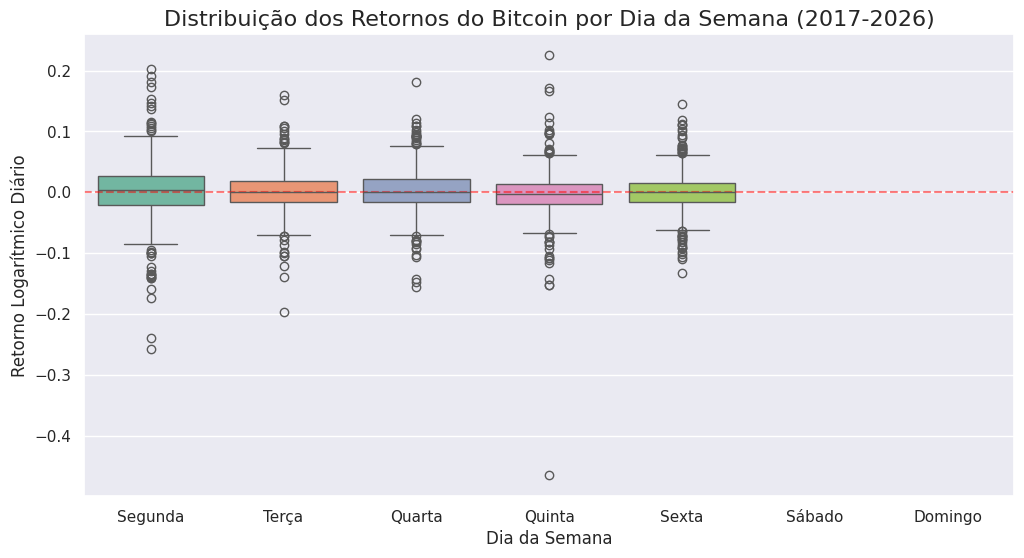

In [69]:
# Criação de uma cópia dos retornos do Bitcoin para análise de sazonalidade semanal
df_btc_sazonalidade = df_retornos_log[['Bitcoin']].copy()

# Extração do dia da semana a partir do índice de data
df_btc_sazonalidade['Dia_da_Semana'] = df_btc_sazonalidade.index.day_name()

# Dicionário de tradução dos dias da semana de inglês para português
dias_pt = {
    'Monday': 'Segunda', 
    'Tuesday': 'Terça', 
    'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 
    'Friday': 'Sexta', 
    'Saturday': 'Sábado', 
    'Sunday': 'Domingo'
}
# Mapeamento e tradução dos dias da semana
df_btc_sazonalidade['Dia_da_Semana'] = df_btc_sazonalidade['Dia_da_Semana'].map(dias_pt)

# Definição da ordem dos dias para exibição no gráfico
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# Configuração do gráfico boxplot para visualizar a distribuição dos retornos
plt.figure(figsize=(12, 6))
sns.boxplot(x='Dia_da_Semana', y='Bitcoin', data=df_btc_sazonalidade, order=ordem_dias, palette='Set2')

# Linha horizontal tracejada indicando retorno neutro (zero)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

# Títulos e formatações dos eixos do gráfico de sazonalidade
plt.title('Distribuição dos Retornos do Bitcoin por Dia da Semana (2017-2026)', fontsize=16)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Retorno Logarítmico Diário', fontsize=12)

# Exibição do gráfico boxplot
plt.show()


#### Conclusão da Análise de Sazonalidade

### 3.2) Correlação com Outros Ativos Financeiros
#### Como os ativos estão correlacionados com o Bitcoin?

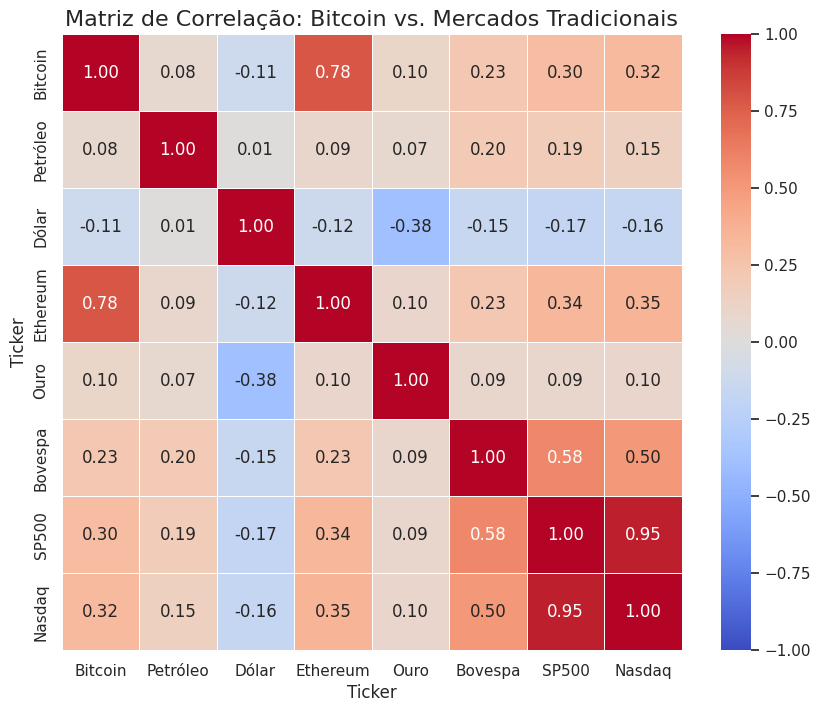

In [70]:
# Garantia de remoção de qualquer valor nulo nos retornos
df_final = df_retornos_log.dropna() 

# Cálculo da matriz de correlação de Pearson entre os retornos dos ativos
matriz_corr = df_final.corr()

# Configuração e plotagem do mapa de calor (heatmap) da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, 
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            fmt=".2f",
            linewidths=0.5)

# Configuração de título e exibição do gráfico de correlação
plt.title('Matriz de Correlação: Bitcoin vs. Mercados Tradicionais', fontsize=16)
plt.show()


#### Conclusão sobre a Correlação


### 3.3) Análise de Volatilidade
#### O Bitcoin realmente é mais volátil?

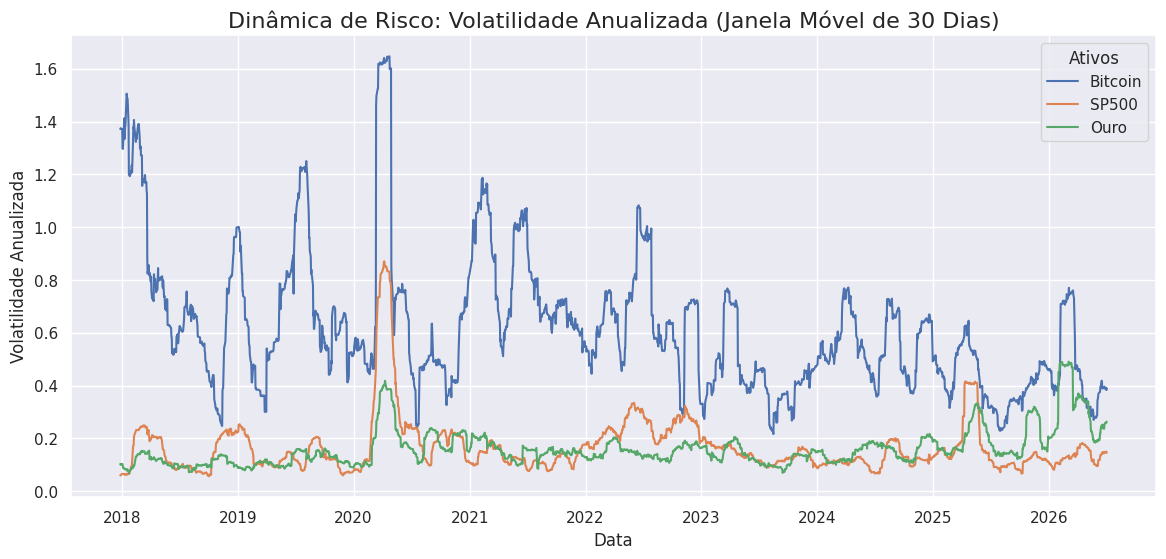

In [71]:
# Definição do tamanho da janela móvel em dias úteis para cálculo de volatilidade
janela = 30

# Cálculo do desvio padrão móvel dos retornos e anualização multiplicando pela raiz de 252
vol_movel = df_retornos_log[['Bitcoin', 'SP500', 'Ouro']].rolling(window=janela).std() * np.sqrt(252)

# Configuração do gráfico de linhas para a volatilidade móvel anualizada
plt.figure(figsize=(14, 6))
sns.lineplot(data=vol_movel, dashes=False, linewidth=1.5)

# Ajustes de legenda, rótulos e título do gráfico
plt.title('Dinâmica de Risco: Volatilidade Anualizada (Janela Móvel de 30 Dias)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Volatilidade Anualizada', fontsize=12)
plt.legend(title='Ativos')

# Exibição do gráfico de volatilidade móvel
plt.show()


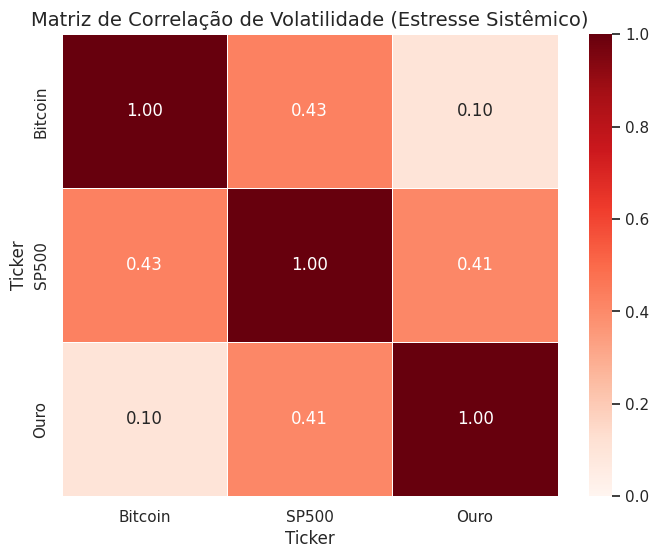

In [72]:
# Definição da janela e cálculo da volatilidade anualizada móvel para Bitcoin, S&P 500 e Ouro
janela = 30
df_volatilidade = df_retornos_log[['Bitcoin', 'SP500', 'Ouro']].rolling(window=janela).std() * np.sqrt(252)

# Remoção de valores nulos iniciais decorrentes da janela móvel
df_volatilidade = df_volatilidade.dropna()

# Cálculo da correlação entre as volatilidades móveis dos ativos para analisar o estresse sistêmico
corr_volatilidade = df_volatilidade.corr()

# Configuração e plotagem do mapa de calor de correlação de volatilidades
plt.figure(figsize=(8, 6))
sns.heatmap(corr_volatilidade, annot=True, cmap='Reds', vmin=0, vmax=1, fmt=".2f", linewidths=0.5)

# Título e exibição do gráfico de correlação de volatilidade
plt.title('Matriz de Correlação de Volatilidade (Estresse Sistêmico)', fontsize=14)
plt.show()


#### 3.4 Risco e Retorno
O Bitcoin é mais arriscado que outros ativos? O retorno compensa o risco?1

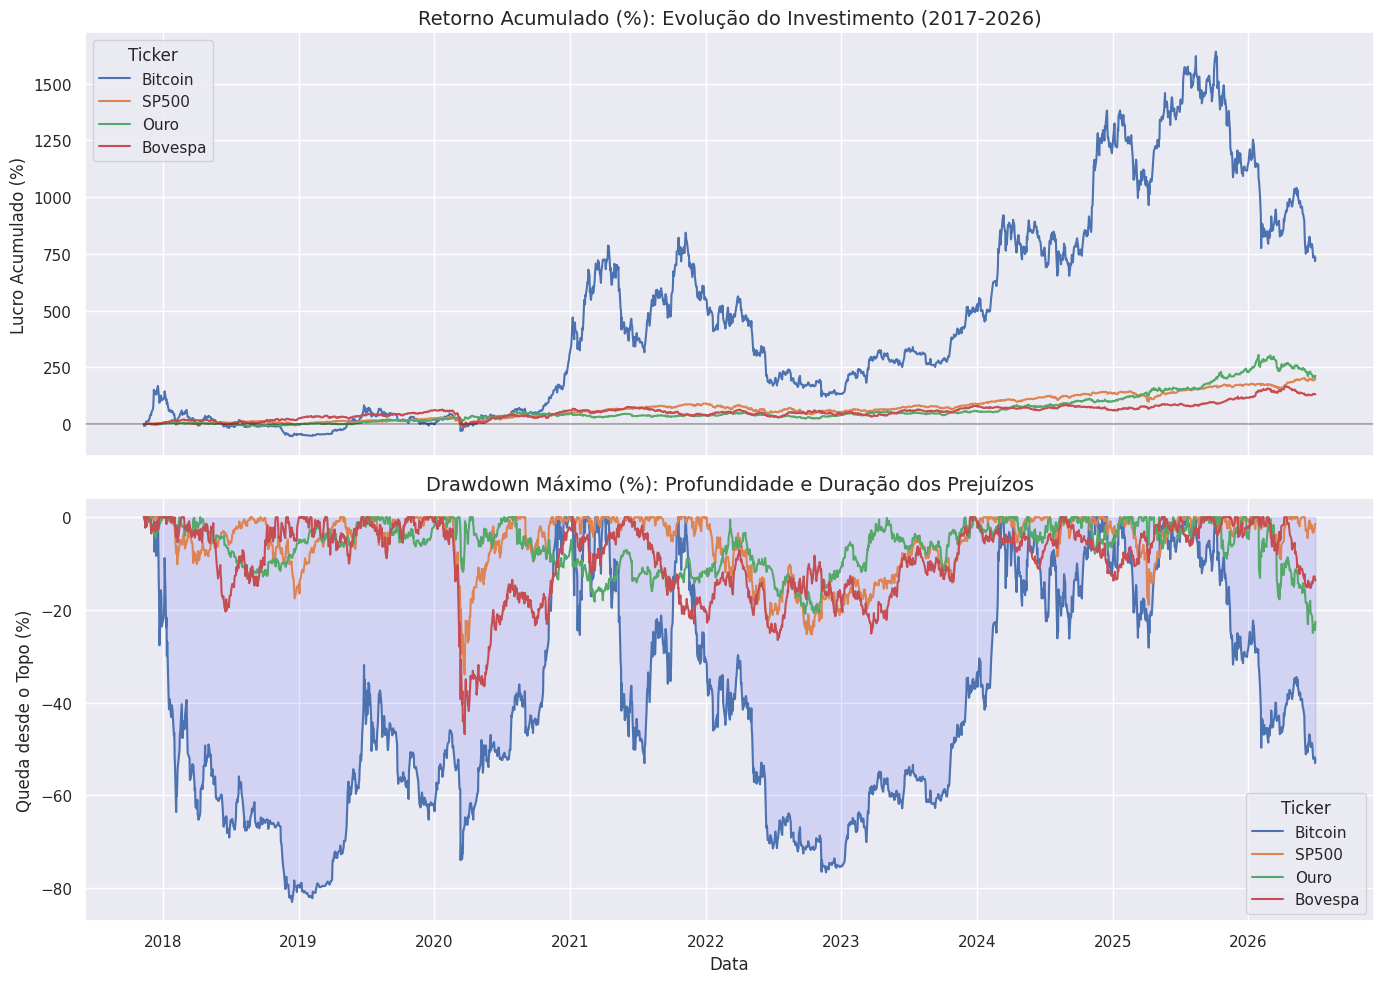

In [73]:
# Cálculo do retorno acumulado de forma exponencial a partir da soma dos retornos logarítmicos
df_acumulado = np.exp(df_retornos_log[['Bitcoin', 'SP500', 'Ouro', 'Bovespa']].cumsum())

# Conversão do retorno acumulado para formato percentual
df_retorno_pct = (df_acumulado - 1) * 100

# Identificação dos picos históricos acumulados (máximo acumulado até cada data)
picos_historicos = df_acumulado.cummax()
# Cálculo do Drawdown diário (queda percentual em relação ao pico histórico atingido anteriormente)
df_drawdown = ((df_acumulado - picos_historicos) / picos_historicos) * 100

# Criação de figura com dois subgráficos compartilhando o mesmo eixo horizontal
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subgráfico 1: Evolução dos retornos percentuais acumulados
sns.lineplot(data=df_retorno_pct, ax=axes[0], dashes=False, linewidth=1.5)
axes[0].set_title('Retorno Acumulado (%): Evolução do Investimento (2017-2026)', fontsize=14)
axes[0].set_ylabel('Lucro Acumulado (%)', fontsize=12)
axes[0].axhline(0, color='black', linestyle='-', alpha=0.3)

# Subgráfico 2: Evolução do Drawdown dos ativos
sns.lineplot(data=df_drawdown, ax=axes[1], dashes=False, linewidth=1.5)
axes[1].set_title('Drawdown Máximo (%): Profundidade e Duração dos Prejuízos', fontsize=14)
axes[1].set_ylabel('Queda desde o Topo (%)', fontsize=12)
axes[1].set_xlabel('Data', fontsize=12)
axes[1].fill_between(df_drawdown.index, df_drawdown['Bitcoin'], 0, color='blue', alpha=0.1)

# Ajuste de layout e exibição do gráfico duplo
plt.tight_layout()
plt.show()


### 3.4.1 Tempo para dobrar capital investido
Quanto tempo cada ativo leva para atingir 100% de rentabilidade?

/tmp/ipykernel_3955/269217858.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Ativo', y='Anos para Dobrar', data=df_tempo_dobrar, palette='viridis')


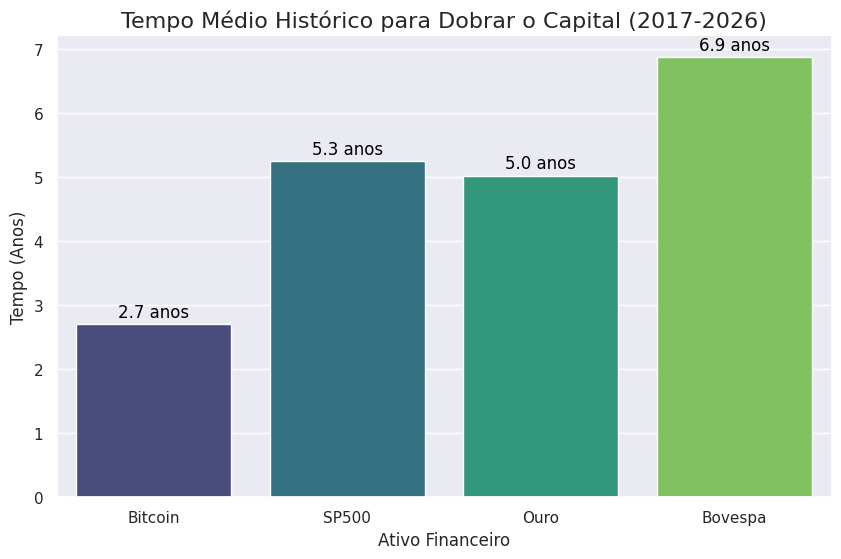

In [74]:
# Calculando o retorno logarítmico médio diário e anualizando (considerando 252 dias úteis)
retorno_medio_diario = df_retornos_log[['Bitcoin', 'SP500', 'Ouro', 'Bovespa']].mean()
retorno_medio_anual = retorno_medio_diario * 252

# Calculando o tempo para dobrar o capital (em anos)
# Usando a fórmula matemática exata: ln(2) / Retorno Anualizado
tempo_dobrar_anos = np.log(2) / retorno_medio_anual

# Convertendo a Série em um DataFrame para facilitar a plotagem no Seaborn
df_tempo_dobrar = tempo_dobrar_anos.reset_index()
df_tempo_dobrar.columns = ['Ativo', 'Anos para Dobrar']

# Plotando o Gráfico de Barras
plt.figure(figsize=(10, 6))
# O palette 'viridis' cria um degradê profissional de cores
ax = sns.barplot(x='Ativo', y='Anos para Dobrar', data=df_tempo_dobrar, palette='viridis')

# Adicionando os rótulos de dados (números) no topo de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f} anos', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Tempo Médio Histórico para Dobrar o Capital (2017-2026)', fontsize=16)
plt.xlabel('Ativo Financeiro', fontsize=12)
plt.ylabel('Tempo (Anos)', fontsize=12)

plt.show()


### 3.4.2 HPR Móvel
Qual a chance de alguém que omprou BTC em um dia aleatório e segurou por 1 ano ter obtido lucro?

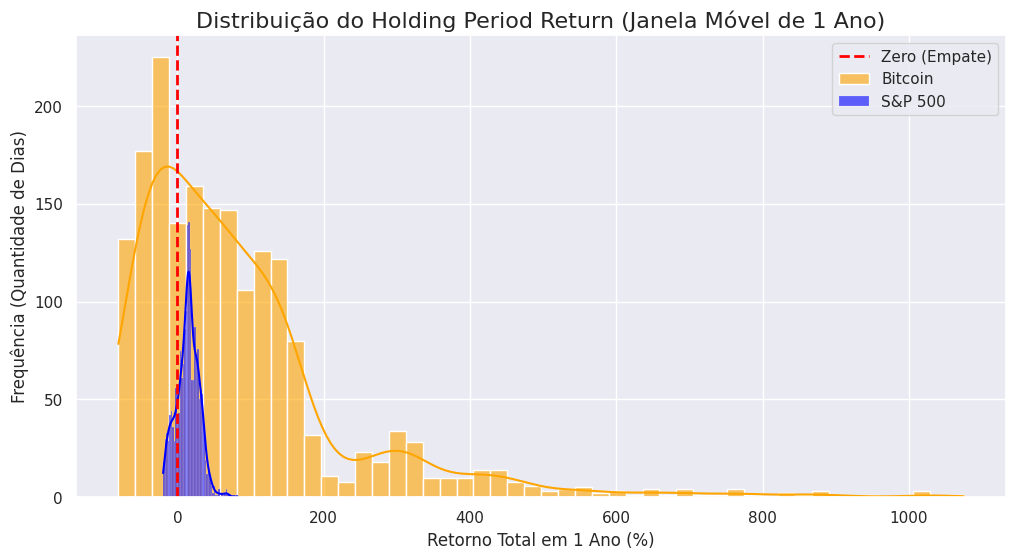

Probabilidade de lucro segurando BTC por 1 ano: 66.9%
Probabilidade de lucro segurando S&P 500 por 1 ano: 81.2%


In [75]:
# Definindo a janela do período de manutenção (ex: 1 ano = 252 dias úteis)
janela_hpr = 252

# Calculando o HPR Móvel (Preço de hoje / Preço de 252 dias atrás - 1)
# Usamos o DataFrame de preços de fechamento originais que foram limpos anteriormente
df_hpr_movel = (df_fechamento / df_fechamento.shift(janela_hpr)) - 1
df_hpr_movel = df_hpr_movel.dropna() * 100 # Em porcentagem

# Plotando a distribuição do HPR de 1 ano (Histograma)
plt.figure(figsize=(12, 6))

sns.histplot(df_hpr_movel['Bitcoin'], bins=50, kde=True, color='orange', alpha=0.6, label='Bitcoin')
sns.histplot(df_hpr_movel['SP500'], bins=50, kde=True, color='blue', alpha=0.6, label='S&P 500')

plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero (Empate)')

plt.title('Distribuição do Holding Period Return (Janela Móvel de 1 Ano)', fontsize=16)
plt.xlabel('Retorno Total em 1 Ano (%)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Dias)', fontsize=12)
plt.legend()


plt.show()

# Calculando a probabilidade de lucro (Taxa de Acerto)
prob_lucro_btc = (df_hpr_movel['Bitcoin'] > 0).mean() * 100
prob_lucro_sp = (df_hpr_movel['SP500'] > 0).mean() * 100

print(f"Probabilidade de lucro segurando BTC por 1 ano: {prob_lucro_btc:.1f}%")
print(f"Probabilidade de lucro segurando S&P 500 por 1 ano: {prob_lucro_sp:.1f}%")


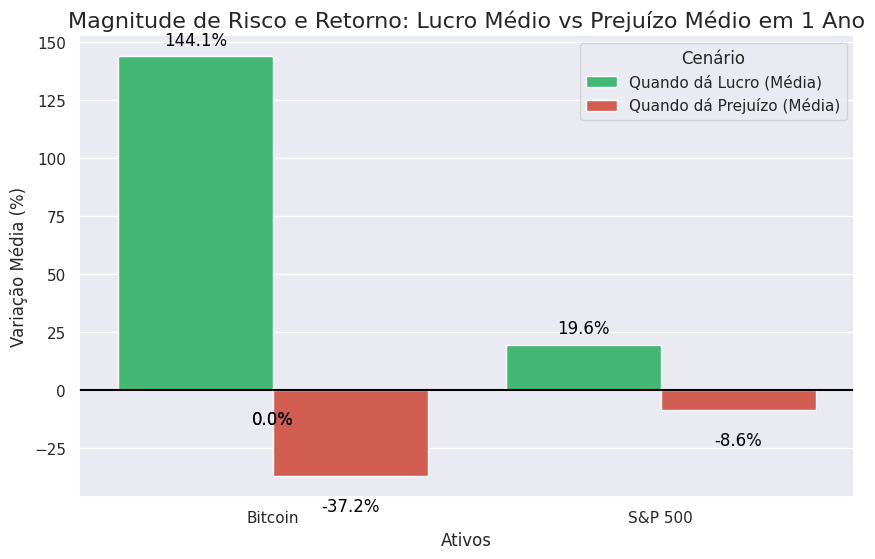

In [ ]:
# Separando os cenários de Lucro e Prejuízo e calculando as médias
lucro_medio_btc = df_hpr_movel[df_hpr_movel['Bitcoin'] > 0]['Bitcoin'].mean()
prejuizo_medio_btc = df_hpr_movel[df_hpr_movel['Bitcoin'] < 0]['Bitcoin'].mean()

lucro_medio_sp = df_hpr_movel[df_hpr_movel['SP500'] > 0]['SP500'].mean()
prejuizo_medio_sp = df_hpr_movel[df_hpr_movel['SP500'] < 0]['SP500'].mean()

# Estruturando os dados para o Seaborn
import pandas as pd # Caso não esteja importado nesta célula

dados_assimetria = pd.DataFrame({81.2%
    'Ativo': ['Bitcoin', 'Bitcoin', 'S&P 500', 'S&P 500'],
    'Cenário': ['Quando dá Lucro (Média)', 'Quando dá Prejuízo (Média)', 'Quando dá Lucro (Média)', 'Quando dá Prejuízo (Média)'],
    'Retorno (%)': [lucro_medio_btc, prejuizo_medio_btc, lucro_medio_sp, prejuizo_medio_sp]
})

# Plotando o Gráfico de Barras Agrupadas
plt.figure(figsize=(10, 6))

# Usando Verde para lucro e Vermelho para prejuízo
cores = ['#2ecc71', '#e74c3c']
ax = sns.barplot(x='Ativo', y='Retorno (%)', hue='Cenário', data=dados_assimetria, palette=cores)

# Colocando os rótulos de dados (os números exatos) nas barras
for p in ax.patches:
    altura = p.get_height()
    # Ajuste de posição dependendo se a barra é positiva ou negativa
    va = 'bottom' if altura > 0 else 'top'
    y_offset = 5 if altura > 0 else -15
    
    ax.annotate(f'{altura:.1f}%', 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va=va, 
                fontsize=12, color='black', xytext=(0, y_offset), 
                textcoords='offset points')

# Linha preta grossa no eixo zero para separar lucros de prejuízos
plt.axhline(0, color='black', linewidth=1.5)

plt.title('Magnitude de Risco e Retorno: Lucro Médio vs Prejuízo Médio em 1 Ano', fontsize=16)
plt.xlabel('Ativos', fontsize=12)
plt.ylabel('Variação Média (%)', fontsize=12)

plt.show()


#### 4. Disclaimer Final ⚠️
Essa é uma análise exploratória envolvendo dados dos mercados analisados e possui limitações inerentes, pois se baseia exclusivamente na observação de padrões visuais e medidas descritivas. O fato de encontrarmos associações não garante que essas diferenças possuam significância estatística, pois podem ser mero fruto do acaso.
Além disso, o Bitcoin é um ativo recente em comparação com os demais analisados, o que dificulta a análise retrospectiva entre eles.
